In [1]:
import os
import sys

# Get the current working directory of the notebook
notebook_dir = os.getcwd()
# Add the parent directory to the system path
sys.path.append(os.path.join(notebook_dir, '../'))

from data_processing import DataProcessing
from data_visualizing import DataPlotting

## Load Data

In [2]:
base_data_path = DataProcessing.load_base_data_path(notebook_dir)

In [3]:
# Define path to all rule-based classification results
classification_dir = os.path.join(base_data_path, 'tense_classification', 'rule_based')

# Discover all dataset folders automatically – no hardcoded list
dataset_folders = [
    f for f in os.listdir(classification_dir)
    if os.path.isdir(os.path.join(classification_dir, f))
]

print(f"Found {len(dataset_folders)} dataset folders: {dataset_folders}")

# Load the latest classifications CSV from each dataset folder
dfs = []
for dataset_name in dataset_folders:
    dataset_dir = os.path.join(classification_dir, dataset_name)

    # Get the latest versioned classifications file (e.g., classifications-v3.csv)
    latest_file = DataProcessing.get_latest_file(
        directory=dataset_dir,
        prefix='classifications',
        file_type='csv',
    )

    file_path = os.path.join(dataset_dir, latest_file)
    print(f"Loading: {file_path}")
    df = DataProcessing.load_from_file(file_path, file_type='csv', sep=',')
    print(f"  Shape: {df.shape}")
    dfs.append(df)

# Concatenate all datasets
combined_df = DataProcessing.concat_dfs(dfs, axis=0, ignore_index=True)
print("\n" + "="*50)
print("COMBINED DATASET")
print("="*50)
print(f"Total shape: {combined_df.shape}")
print(f"Datasets included: {len(dfs)}")
print(f"\nDataset distribution:")
# print(combined_df['Dataset'].value_counts())
print(f"\nPreview:")
print(combined_df.head())

Found 3 dataset folders: ['chronicle2050', 'financial_phrasebank_imbalanced', 'synthetic_combined']
Loading: /Users/detraviousjamaribrinkley/Documents/Development/research_labs/uf_ds/predictions/notebook_experiments/../data/tense_classification/rule_based/chronicle2050/classifications-v1.csv
  Shape: (6402, 3)
Loading: /Users/detraviousjamaribrinkley/Documents/Development/research_labs/uf_ds/predictions/notebook_experiments/../data/tense_classification/rule_based/financial_phrasebank_imbalanced/classifications-v1.csv
  Shape: (4846, 3)
Loading: /Users/detraviousjamaribrinkley/Documents/Development/research_labs/uf_ds/predictions/notebook_experiments/../data/tense_classification/rule_based/synthetic_combined/classifications-v1.csv
  Shape: (2044, 3)

COMBINED DATASET
Total shape: (13292, 3)
Datasets included: 3

Dataset distribution:

Preview:
                                            Sentence  Future Tense  \
0  By January 1st, 2037, Tesla will have been the...             1   
1  An

In [4]:
combined_df

,Sentence,Future Tense,Source Dataset
0,"By January 1st, 2037, Tesla will have been the...",1,tense_extraction/chronicle2050/pos_features-v1...
1,An annual average temperature anomaly value ab...,1,tense_extraction/chronicle2050/pos_features-v1...
2,Private Nonfarm business productivity growth w...,1,tense_extraction/chronicle2050/pos_features-v1...
3,No Republican will be President of the USA bef...,1,tense_extraction/chronicle2050/pos_features-v1...
4,The market capitalization of Berkshire Hathawa...,1,tense_extraction/chronicle2050/pos_features-v1...
...,...,...,...
13287,"On Q2 of 2025, Coach Ryan Thompson observed th...",0,tense_extraction/synthetic_combined/pos_featur...
13288,"George noted that on August 28, 2024, the save...",0,tense_extraction/synthetic_combined/pos_featur...
13289,According to the staff of the Los Angeles Lake...,0,tense_extraction/synthetic_combined/pos_featur...
13290,"In Q4 of 2027, Analyst Daniel Kim recorded tha...",0,tense_extraction/synthetic_combined/pos_featur...


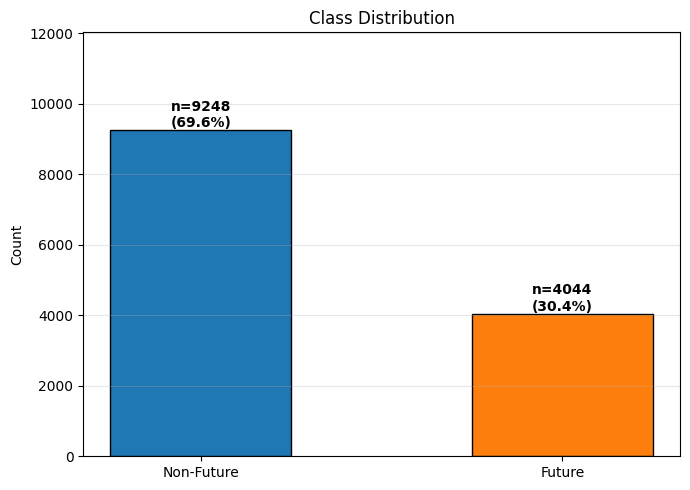

In [5]:
DataPlotting.plot_class_distribution(combined_df, label_col='Future Tense', class_names=['Non-Future', 'Future'])

In [6]:
filt_future = (combined_df['Future Tense'] == 1)
future_df = combined_df[filt_future]
future_df

,Sentence,Future Tense,Source Dataset
0,"By January 1st, 2037, Tesla will have been the...",1,tense_extraction/chronicle2050/pos_features-v1...
1,An annual average temperature anomaly value ab...,1,tense_extraction/chronicle2050/pos_features-v1...
2,Private Nonfarm business productivity growth w...,1,tense_extraction/chronicle2050/pos_features-v1...
3,No Republican will be President of the USA bef...,1,tense_extraction/chronicle2050/pos_features-v1...
4,The market capitalization of Berkshire Hathawa...,1,tense_extraction/chronicle2050/pos_features-v1...
...,...,...,...
12178,"In 2029, game developer David Kim envisions th...",1,tense_extraction/synthetic_combined/pos_featur...
12179,The stock price of Amazon should stay the same...,1,tense_extraction/synthetic_combined/pos_featur...
12414,"In Q2 2029, the college student researching th...",1,tense_extraction/synthetic_combined/pos_featur...
12828,"In Q2 of 2028, Professor Jones envisioned that...",1,tense_extraction/synthetic_combined/pos_featur...


In [7]:
save_path = os.path.join(classification_dir, 'combined')
DataProcessing.save_to_file(future_df, save_path, prefix='future-chronicle2050_fpb_synthethic', save_file_type='csv')

Using file number: 1
Saving CSV file to: /Users/detraviousjamaribrinkley/Documents/Development/research_labs/uf_ds/predictions/notebook_experiments/../data/tense_classification/rule_based/combined/future-chronicle2050_fpb_synthethic-v1.csv
